# InfluxDB Plant Watering Data Analysis

This notebook processes exported InfluxDB data from three ESP-based irrigation systems:
- **esp_2_timer_irrigation** — Timer-based irrigation
- **esp_3_threshold_irrigation** — Threshold-based irrigation
- **esp_4_adaptive_irrigation** — Adaptive irrigation

The raw InfluxDB annotated CSV (long format) is parsed, pivoted to wide format,
split into per-device DataFrames, and key metrics are aggregated.

## 1. Upload Data & Import Libraries

In [93]:
import pandas as pd
import numpy as np
from google.colab import files

## 2. Read & Clean the InfluxDB Annotated CSV

InfluxDB exports include 3 annotation header rows (`#group`, `#datatype`, `#default`)
followed by the actual column header. We skip the annotation rows and filter out any
residual metadata rows that leak into the data.

In [94]:
# Read CSV, skipping the 3 InfluxDB annotation rows
raw = pd.read_csv("influx.data-4.csv", skiprows=3)

print(f'Raw shape: {raw.shape}')
print(f'Columns:   {raw.columns.tolist()}')
raw.head()

Raw shape: (6652, 11)
Columns:   ['Unnamed: 0', 'result', 'table', '_start', '_stop', '_time', '_value', '_field', '_measurement', 'device', 'phase']


,Unnamed: 0,result,table,_start,_stop,_time,_value,_field,_measurement,device,phase
0,NaN,NaN,0,2026-03-17T14:00:00Z,2026-03-24T12:00:00Z,2026-03-17T14:24:00Z,1522,load_grams,plant_watering,esp_2_timer_irrigation,post
1,NaN,NaN,0,2026-03-17T14:00:00Z,2026-03-24T12:00:00Z,2026-03-17T15:23:24Z,1521,load_grams,plant_watering,esp_2_timer_irrigation,post
2,NaN,NaN,0,2026-03-17T14:00:00Z,2026-03-24T12:00:00Z,2026-03-17T16:22:53Z,1520,load_grams,plant_watering,esp_2_timer_irrigation,post
3,NaN,NaN,0,2026-03-17T14:00:00Z,2026-03-24T12:00:00Z,2026-03-17T17:22:19Z,1521,load_grams,plant_watering,esp_2_timer_irrigation,post
4,NaN,NaN,0,2026-03-17T14:00:00Z,2026-03-24T12:00:00Z,2026-03-17T18:21:46Z,1380,load_grams,plant_watering,esp_2_timer_irrigation,post


In [95]:
# Keep only rows that belong to one of the three target devices
DEVICES = [
    'esp_2_timer_irrigation',
    'esp_3_threshold_irrigation',
    'esp_4_adaptive_irrigation'
]

df = raw[raw['device'].isin(DEVICES)].copy()

# Keep only the columns we need for pivoting
df = df[['_time', '_value', '_field', 'device']].copy()

# Convert _value to numeric (coerce non-numeric → NaN)
df['_value'] = pd.to_numeric(df['_value'], errors='coerce')

print(f'Filtered shape: {df.shape}')
print(f'Unique fields:  {sorted(df["_field"].unique())}')
print(f'Unique devices: {sorted(df["device"].unique())}')

Filtered shape: (6580, 4)
Unique fields:  ['humidity_rh', 'load_grams', 'logic_ms', 'pump_and_post_sensor_ms', 'pump_ms', 'pump_used', 'sensor_ms', 'soil_pct', 'soil_raw', 'temp_c', 'total_awake_ms', 'water_used', 'wifi_ms']
Unique devices: ['esp_2_timer_irrigation', 'esp_3_threshold_irrigation', 'esp_4_adaptive_irrigation']


## 3. Pivot from Long to Wide Format

Each `(_time, device)` combination has multiple rows — one per `_field`.
We pivot so that every field becomes its own column.

In [96]:
# Pivot: rows = (timestamp, device), columns = _field, values = _value
wide = df.pivot_table(
    index=['_time', 'device'],
    columns='_field',
    values='_value',
    aggfunc='first'       # one value per (time, device, field)
).reset_index()

# Flatten the MultiIndex column names
wide.columns.name = None

print(f'Wide shape: {wide.shape}')
wide.head()

Wide shape: (470, 15)


,_time,device,humidity_rh,load_grams,logic_ms,pump_and_post_sensor_ms,pump_ms,pump_used,sensor_ms,soil_pct,soil_raw,temp_c,total_awake_ms,water_used,wifi_ms
0,2026-03-17T14:17:40Z,esp_4_adaptive_irrigation,55.20,1476.0,0.0,0.0,0.0,0.0,79.0,59.5,2259.0,17.85,1899.0,0.0,1819.0
1,2026-03-17T14:23:23Z,esp_3_threshold_irrigation,0.00,1509.0,0.0,0.0,0.0,0.0,209.0,55.9,2310.0,0.00,11049.0,0.0,10839.0
2,2026-03-17T14:24:00Z,esp_2_timer_irrigation,55.49,1522.0,0.0,0.0,0.0,0.0,89.0,38.6,2556.0,17.50,5719.0,0.0,5629.0
3,2026-03-17T15:17:06Z,esp_4_adaptive_irrigation,55.22,1475.0,0.0,0.0,0.0,0.0,69.0,57.5,2288.0,18.01,3149.0,0.0,3079.0
4,2026-03-17T15:22:51Z,esp_3_threshold_irrigation,0.00,1508.0,0.0,0.0,0.0,0.0,209.0,56.0,2309.0,0.00,2059.0,0.0,1849.0


## 4. Rename & Select Final Columns

Target schema:  
`timestamp, device, humidity_rh, load_grams, logic_ms, pump_and_post_sensor_ms,`
`pump_ms, pump_used, sensor_ms, soil_pct, temp_c, total_awake_ms, water_used_ms, wifi_ms`

In [97]:
# Rename _time → timestamp and water_used → water_used_ms
wide = wide.rename(columns={
    '_time': 'timestamp',
})

# Make water_used values positive, wrong substraction in fw
wide['water_used'] = wide['water_used'].abs()

# Convert timestamp to datetime
wide['timestamp'] = pd.to_datetime(wide['timestamp'])

# Define the final column order
FINAL_COLS = [
    'timestamp','device', 'humidity_rh', 'load_grams', 'logic_ms', 'pump_and_post_sensor_ms', 'pump_ms', 'pump_used', 'sensor_ms', 'soil_pct', 'soil_raw', 'temp_c', 'total_awake_ms', 'water_used', 'wifi_ms'
]

# Keep only the requested columns (ignore any extras like soil_raw)
available = [c for c in FINAL_COLS if c in wide.columns]
missing   = [c for c in FINAL_COLS if c not in wide.columns]
if missing:
    print(f'⚠ Columns not found in data (will be skipped): {missing}')

wide = wide[available].sort_values(['device', 'timestamp']).reset_index(drop=True)

print(f'Final shape: {wide.shape}')
print(f'Columns:     {wide.columns.tolist()}')
wide.head()

Final shape: (470, 15)
Columns:     ['timestamp', 'device', 'humidity_rh', 'load_grams', 'logic_ms', 'pump_and_post_sensor_ms', 'pump_ms', 'pump_used', 'sensor_ms', 'soil_pct', 'soil_raw', 'temp_c', 'total_awake_ms', 'water_used', 'wifi_ms']


,timestamp,device,humidity_rh,load_grams,logic_ms,pump_and_post_sensor_ms,pump_ms,pump_used,sensor_ms,soil_pct,soil_raw,temp_c,total_awake_ms,water_used,wifi_ms
0,2026-03-17 14:24:00+00:00,esp_2_timer_irrigation,55.49,1522.0,0.0,0.0,0.0,0.0,89.0,38.6,2556.0,17.50,5719.0,0.0,5629.0
1,2026-03-17 15:23:24+00:00,esp_2_timer_irrigation,55.89,1521.0,0.0,0.0,0.0,0.0,89.0,39.5,2543.0,17.65,2099.0,0.0,2009.0
2,2026-03-17 16:22:53+00:00,esp_2_timer_irrigation,56.23,1520.0,0.0,0.0,0.0,0.0,89.0,39.3,2546.0,17.45,1959.0,0.0,1869.0
3,2026-03-17 17:22:19+00:00,esp_2_timer_irrigation,56.45,1521.0,0.0,0.0,0.0,0.0,89.0,39.5,2543.0,17.22,1939.0,0.0,1849.0
4,2026-03-17 18:21:46+00:00,esp_2_timer_irrigation,57.76,1380.0,0.0,0.0,0.0,0.0,89.0,41.2,2519.0,17.23,1839.0,0.0,1749.0


## 5. Split into Per-Device DataFrames

In [98]:
df_esp2_timer     = wide[wide['device'] == 'esp_2_timer_irrigation'].reset_index(drop=True)
df_esp3_threshold = wide[wide['device'] == 'esp_3_threshold_irrigation'].reset_index(drop=True)
df_esp4_adaptive  = wide[wide['device'] == 'esp_4_adaptive_irrigation'].reset_index(drop=True)

print(f'esp_2_timer_irrigation      : {df_esp2_timer.shape[0]} rows')
print(f'esp_3_threshold_irrigation  : {df_esp3_threshold.shape[0]} rows')
print(f'esp_4_adaptive_irrigation   : {df_esp4_adaptive.shape[0]} rows')

esp_2_timer_irrigation      : 156 rows
esp_3_threshold_irrigation  : 147 rows
esp_4_adaptive_irrigation   : 167 rows


In [99]:
print('=== esp_2_timer_irrigation (first 5 rows) ===')
display(df_esp2_timer.head())

print('\n=== esp_3_threshold_irrigation (first 5 rows) ===')
display(df_esp3_threshold.head())

print('\n=== esp_4_adaptive_irrigation (first 5 rows) ===')
display(df_esp4_adaptive.head())

=== esp_2_timer_irrigation (first 5 rows) ===


,timestamp,device,humidity_rh,load_grams,logic_ms,pump_and_post_sensor_ms,pump_ms,pump_used,sensor_ms,soil_pct,soil_raw,temp_c,total_awake_ms,water_used,wifi_ms
0,2026-03-17 14:24:00+00:00,esp_2_timer_irrigation,55.49,1522.0,0.0,0.0,0.0,0.0,89.0,38.6,2556.0,17.50,5719.0,0.0,5629.0
1,2026-03-17 15:23:24+00:00,esp_2_timer_irrigation,55.89,1521.0,0.0,0.0,0.0,0.0,89.0,39.5,2543.0,17.65,2099.0,0.0,2009.0
2,2026-03-17 16:22:53+00:00,esp_2_timer_irrigation,56.23,1520.0,0.0,0.0,0.0,0.0,89.0,39.3,2546.0,17.45,1959.0,0.0,1869.0
3,2026-03-17 17:22:19+00:00,esp_2_timer_irrigation,56.45,1521.0,0.0,0.0,0.0,0.0,89.0,39.5,2543.0,17.22,1939.0,0.0,1849.0
4,2026-03-17 18:21:46+00:00,esp_2_timer_irrigation,57.76,1380.0,0.0,0.0,0.0,0.0,89.0,41.2,2519.0,17.23,1839.0,0.0,1749.0



=== esp_3_threshold_irrigation (first 5 rows) ===


,timestamp,device,humidity_rh,load_grams,logic_ms,pump_and_post_sensor_ms,pump_ms,pump_used,sensor_ms,soil_pct,soil_raw,temp_c,total_awake_ms,water_used,wifi_ms
0,2026-03-17 14:23:23+00:00,esp_3_threshold_irrigation,0.0,1509.0,0.0,0.0,0.0,0.0,209.0,55.9,2310.0,0.0,11049.0,0.0,10839.0
1,2026-03-17 15:22:51+00:00,esp_3_threshold_irrigation,0.0,1508.0,0.0,0.0,0.0,0.0,209.0,56.0,2309.0,0.0,2059.0,0.0,1849.0
2,2026-03-17 16:22:16+00:00,esp_3_threshold_irrigation,0.0,1507.0,0.0,0.0,0.0,0.0,209.0,54.7,2328.0,0.0,2299.0,0.0,2090.0
3,2026-03-17 17:21:43+00:00,esp_3_threshold_irrigation,0.0,1510.0,0.0,0.0,0.0,0.0,209.0,56.1,2307.0,0.0,2619.0,0.0,2409.0
4,2026-03-17 18:21:08+00:00,esp_3_threshold_irrigation,0.0,1509.0,0.0,0.0,0.0,0.0,209.0,57.1,2293.0,0.0,2199.0,0.0,1989.0



=== esp_4_adaptive_irrigation (first 5 rows) ===


,timestamp,device,humidity_rh,load_grams,logic_ms,pump_and_post_sensor_ms,pump_ms,pump_used,sensor_ms,soil_pct,soil_raw,temp_c,total_awake_ms,water_used,wifi_ms
0,2026-03-17 14:17:40+00:00,esp_4_adaptive_irrigation,55.20,1476.0,0.0,0.0,0.0,0.0,79.0,59.5,2259.0,17.85,1899.0,0.0,1819.0
1,2026-03-17 15:17:06+00:00,esp_4_adaptive_irrigation,55.22,1475.0,0.0,0.0,0.0,0.0,69.0,57.5,2288.0,18.01,3149.0,0.0,3079.0
2,2026-03-17 16:16:33+00:00,esp_4_adaptive_irrigation,56.21,1474.0,0.0,0.0,0.0,0.0,69.0,58.7,2271.0,17.66,1789.0,0.0,1719.0
3,2026-03-17 17:15:54+00:00,esp_4_adaptive_irrigation,57.60,1471.0,0.0,0.0,0.0,0.0,79.0,58.5,2273.0,17.39,1729.0,0.0,1649.0
4,2026-03-17 18:15:21+00:00,esp_4_adaptive_irrigation,58.19,1470.0,0.0,0.0,0.0,0.0,79.0,58.8,2269.0,17.45,1559.0,0.0,1479.0


## 6. Cumulative Totals — `pump_ms`, `water_used_ms`, `total_awake_ms`

Sum these three columns across all rows for each device.

In [100]:
SUM_COLS = ['pump_ms', 'water_used', 'total_awake_ms']

totals = {}
for name, df_dev in [
    ('esp_2_timer_irrigation',     df_esp2_timer),
    ('esp_3_threshold_irrigation', df_esp3_threshold),
    ('esp_4_adaptive_irrigation',  df_esp4_adaptive),
]:
    sums = {col: df_dev[col].sum() for col in SUM_COLS if col in df_dev.columns}
    totals[name] = sums

df_totals = pd.DataFrame(totals).T
df_totals.index.name = 'device'

print('Cumulative totals per device:')
display(df_totals)

Cumulative totals per device:


,pump_ms,water_used,total_awake_ms
device,,,
esp_2_timer_irrigation,12000.0,254.0,619234.0
esp_3_threshold_irrigation,352000.0,0.0,935773.0
esp_4_adaptive_irrigation,40358.0,498.0,387576.0


## 7. Average Values — `sensor_ms`, `pump_ms`, `total_awake_ms`, `pump_and_post_sensor_ms`, `logic_ms`

Compute the mean of each timing column per device.

In [101]:
AVG_COLS = ['sensor_ms', 'pump_ms', 'total_awake_ms',
            'pump_and_post_sensor_ms', 'logic_ms', 'soil_pct']

averages = {}
for name, df_dev in [
    ('esp_2_timer_irrigation',     df_esp2_timer),
    ('esp_3_threshold_irrigation', df_esp3_threshold),
    ('esp_4_adaptive_irrigation',  df_esp4_adaptive),
]:
    means = {col: df_dev[col].mean() for col in AVG_COLS if col in df_dev.columns}
    averages[name] = means

df_averages = pd.DataFrame(averages).T
df_averages.index.name = 'device'

print('Average values per device:')
display(df_averages.round(2))

Average values per device:


,sensor_ms,pump_ms,total_awake_ms,pump_and_post_sensor_ms,logic_ms,soil_pct
device,,,,,,
esp_2_timer_irrigation,87.08,76.92,3969.45,0.00,77.74,49.29
esp_3_threshold_irrigation,209.00,2394.56,6365.80,2394.78,0.00,44.73
esp_4_adaptive_irrigation,74.27,241.66,2320.81,0.00,242.96,54.97


## 8. Quick Comparison Table

In [102]:
# Side-by-side: totals and averages
summary = df_totals.add_suffix('_total').join(df_averages.add_suffix('_avg'))
display(summary.round(2))

,pump_ms_total,water_used_total,total_awake_ms_total,sensor_ms_avg,pump_ms_avg,total_awake_ms_avg,pump_and_post_sensor_ms_avg,logic_ms_avg,soil_pct_avg
device,,,,,,,,,
esp_2_timer_irrigation,12000.0,254.0,619234.0,87.08,76.92,3969.45,0.00,77.74,49.29
esp_3_threshold_irrigation,352000.0,0.0,935773.0,209.00,2394.56,6365.80,2394.78,0.00,44.73
esp_4_adaptive_irrigation,40358.0,498.0,387576.0,74.27,241.66,2320.81,0.00,242.96,54.97


In [103]:
# Calculate total pump activations (sum of pump_used) per device
pump_used_totals = wide.groupby('device')['pump_used'].sum().reset_index()

print("Total Pump Activations per System:")
display(pump_used_totals)

Total Pump Activations per System:


,device,pump_used
0,esp_2_timer_irrigation,3.0
1,esp_3_threshold_irrigation,88.0
2,esp_4_adaptive_irrigation,6.0


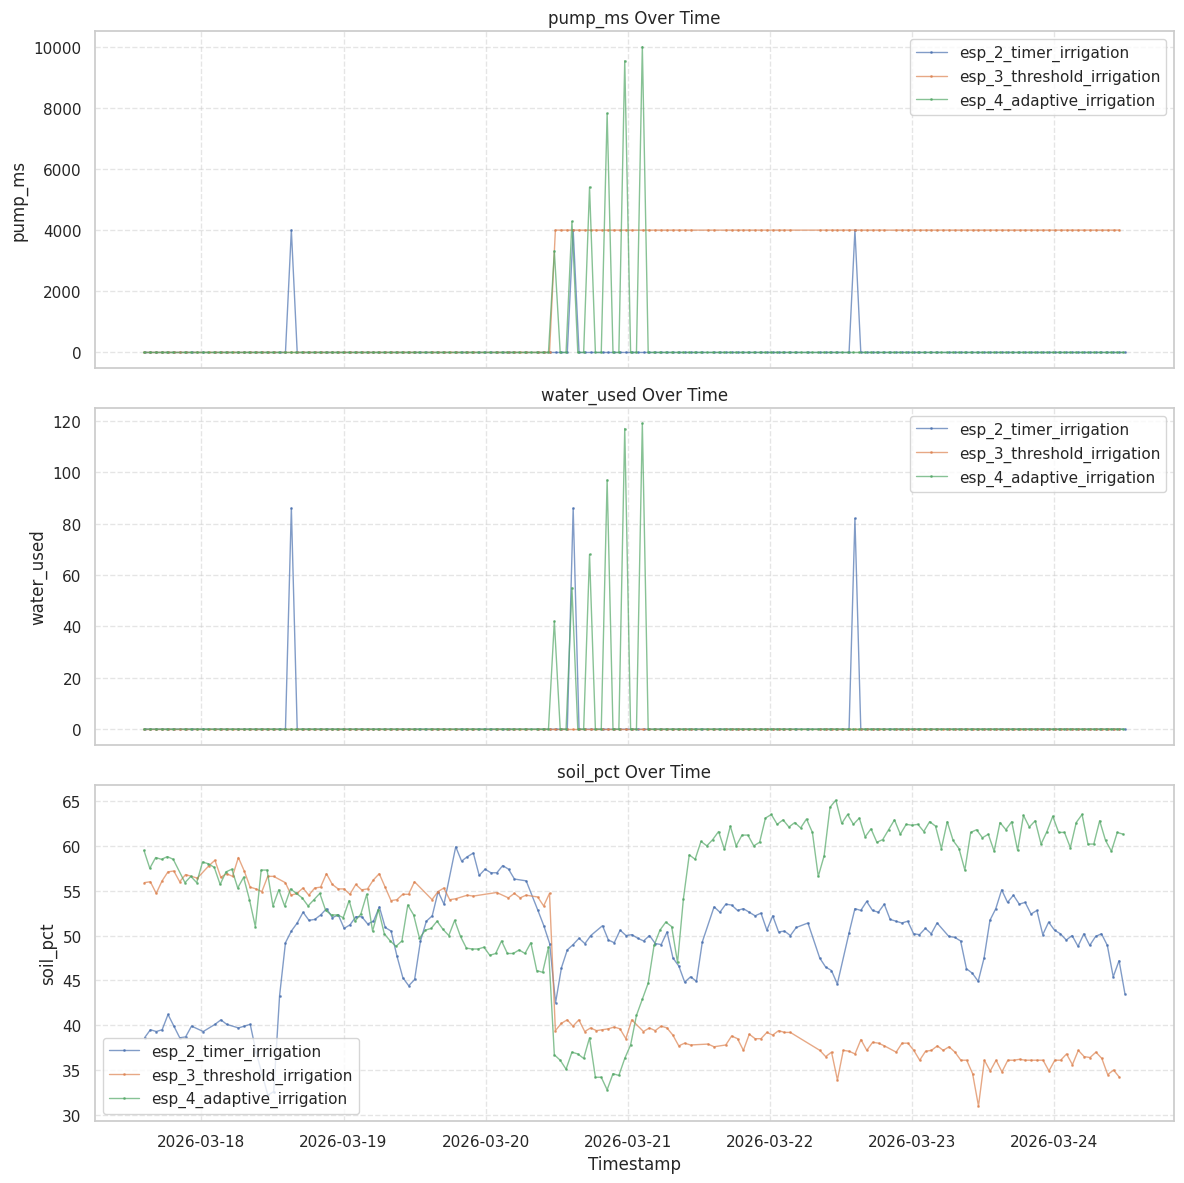

In [104]:
import matplotlib.pyplot as plt

# Group data by device to plot each system separately or on shared axes
devices = wide['device'].unique()
metrics = ['pump_ms', 'water_used', 'soil_pct']

fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 12), sharex=True)

for i, metric in enumerate(metrics):
    for device in devices:
        device_data = wide[wide['device'] == device]
        # Reduced markersize to 1 for better visibility of overlaps
        axes[i].plot(device_data['timestamp'], device_data[metric], label=device, marker='o', markersize=1, alpha=0.7, linewidth=1)

    axes[i].set_title(f'{metric} Over Time')
    axes[i].set_ylabel(metric)
    axes[i].legend()
    axes[i].grid(True, which='both', linestyle='--', alpha=0.5)

plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()

In [105]:
# Current draw constants (mA)
I_WIFI = 62.45
I_ACTIVE = 25.28
I_SLEEP = 1.2
I_PUMP = 115.0
T_SLEEP_MS = 3600000.0 # 1 hour in ms

# 1. Calculate Active Charge (mA-ms)
wide['charge_active_mams'] = (wide['wifi_ms'] * I_WIFI) + ((wide['total_awake_ms'] - wide['wifi_ms']) * I_ACTIVE)

# 2. Calculate Pump Charge (mA-ms)
wide['charge_pump_mams'] = wide['pump_ms'] * I_PUMP

# 3. Calculate Sleep Charge (mA-ms)
wide['charge_sleep_mams'] = T_SLEEP_MS * I_SLEEP

# Group by device
current_summary = wide.groupby('device').agg({
    'total_awake_ms': 'sum',
    'pump_ms': 'sum',
    'charge_active_mams': 'sum',
    'charge_pump_mams': 'sum',
    'charge_sleep_mams': 'sum',
    'timestamp': 'count'
}).reset_index()

current_summary.rename(columns={'timestamp': 'cycle_count'}, inplace=True)

# Totals in mAh
current_summary['active_only_mah'] = current_summary['charge_active_mams'] / 3600000.0
current_summary['pump_only_mah'] = current_summary['charge_pump_mams'] / 3600000.0
current_summary['sleep_only_mah'] = current_summary['charge_sleep_mams'] / 3600000.0
current_summary['total_charge_mah'] = current_summary['active_only_mah'] + current_summary['pump_only_mah'] + current_summary['sleep_only_mah']

print("Full Energy Analysis (Active + Pump + Deep Sleep):")
display(current_summary[['device', 'cycle_count', 'active_only_mah', 'pump_only_mah', 'sleep_only_mah', 'total_charge_mah']].round(4))

Full Energy Analysis (Active + Pump + Deep Sleep):


,device,cycle_count,active_only_mah,pump_only_mah,sleep_only_mah,total_charge_mah
0,esp_2_timer_irrigation,156,10.4749,0.3833,187.2,198.0583
1,esp_3_threshold_irrigation,147,12.2796,11.2444,176.4,199.9241
2,esp_4_adaptive_irrigation,167,6.1747,1.2892,200.4,207.8640
